# Amazon Product Review Sentiment Analysis with NLP and Machine Learning

This project explores Amazon product review data using exploratory data analysis (EDA), natural language processing (NLP), sentiment analysis, and machine learning techniques.

The project includes:

- Product rating distribution analysis
- Category-level performance evaluation
- Custom product scoring and value analysis
- Text preprocessing and word frequency analysis
- Word cloud visualization
- Sentiment analysis using TextBlob
- TF-IDF feature extraction
- Logistic Regression sentiment classification
- Model evaluation using classification metrics and confusion matrix
- Predictive word analysis for positive and negative sentiment
- Business insights derived from customer review patterns

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from nltk.corpus import stopwords
from wordcloud import WordCloud

from textblob import TextBlob

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

The following libraries were imported for data analysis, visualization, natural language processing, sentiment analysis, and machine learning tasks.

## Upload Dataset

In [2]:
df = pd.read_csv("amazon.csv")
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


The Amazon product review dataset was loaded into a pandas DataFrame for data cleaning, exploratory analysis, NLP preprocessing, and machine learning tasks.

## Dataset Information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

## Data Cleaning and Type Conversion

Several preprocessing steps were applied to convert pricing, discount, rating, and review count variables into numerical formats suitable for analysis.

Currency symbols, percentage signs, and comma separators were removed before type conversion. Invalid numeric entries were coerced into missing values where necessary.

In [4]:
df["discounted_price"] = (
    df["discounted_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["actual_price"] = (
    df["actual_price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

df["discount_percentage"] = (
    df["discount_percentage"]
    .str.replace("%", "", regex=False)
    .astype(float)
)

df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)

df["rating_count"] = (
    df["rating_count"]
    .str.replace(",", "", regex=False)
)

df["rating_count"] = pd.to_numeric(
    df["rating_count"],
    errors="coerce"
)

## Missing Values Analysis

In [5]:
df.isna().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 1
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

A small number of missing values appeared in the rating and rating_count variables after preprocessing and type conversion.

These missing observations originated from invalid textual entries and inconsistent formatting that were automatically coerced into NaN values during numeric conversion.

## Missing Value Handling

In [6]:
df = df.dropna(subset=["rating","rating_count"])

Rows containing missing values in the rating and rating_count variables were removed to ensure data consistency and avoid issues during statistical analysis and machine learning modeling.

## Exploratory Data Analysis

### Descriptive Statistics

In [7]:
df.describe()

,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,47.672367,4.096717,18307.376881
std,6950.548042,10884.467444,21.613905,0.289497,42766.096572
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.500000
50%,799.000000,1670.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4321.250000,63.000000,4.300000,17342.250000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


- The dataset contains 1,462 products.
- The average discounted price is ₹3,130, while the average actual price is ₹5,453, indicating that products are commonly sold at substantial discounts.
- The mean prices are considerably higher than the median values, suggesting right-skewed price distributions driven by a small number of premium products.
- The average discount percentage is approximately 47.7%, with discounts ranging from 0% to 94%.
- Customer ratings are generally high, with an average rating of 4.10 out of 5.
- Rating counts are highly skewed, as a small number of popular products receive exceptionally large numbers of reviews.
- Overall, the dataset contains substantial variation in pricing, discounts, and review activity, making it suitable for customer behavior and sentiment analysis.

### Rating Distribution Analysis

Text(0, 0.5, 'Frequency')

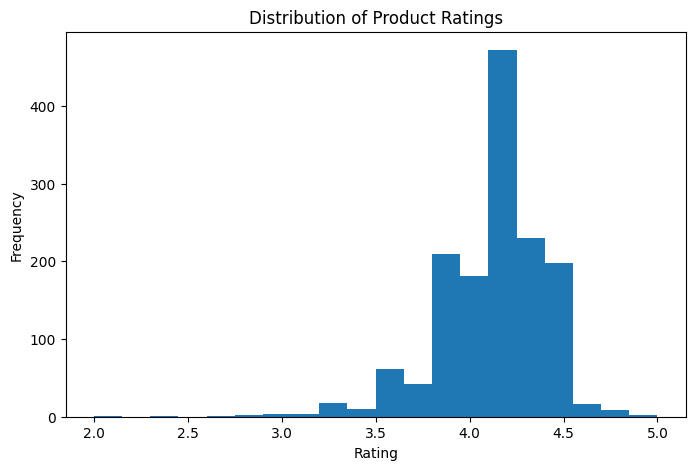

In [8]:
plt.figure(figsize=(8,5))

plt.hist(df["rating"], bins=20)

plt.title("Distribution of Product Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

Customer ratings are heavily concentrated between 4.0 and 4.5, indicating that most products receive favorable reviews. Low-rated products are relatively rare, resulting in a negatively skewed distribution.

### Discount vs Rating 

Text(0, 0.5, 'Rating')

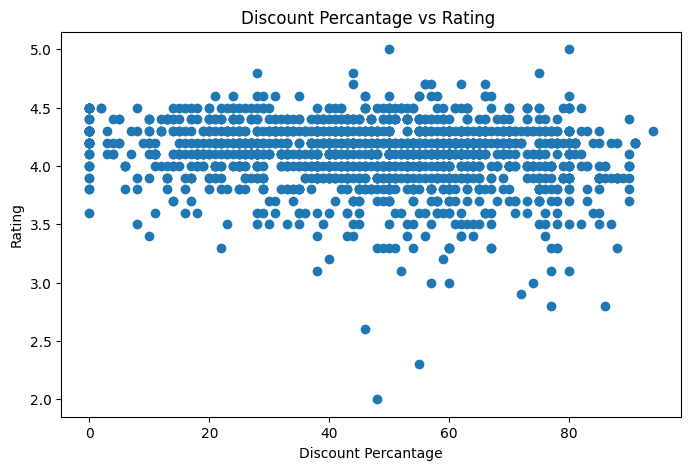

In [9]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["discount_percentage"],
    df["rating"]
)

plt.title("Discount Percantage vs Rating ")
plt.xlabel("Discount Percantage")
plt.ylabel("Rating")

In [10]:
correlation = df["discount_percentage"].corr(df["rating"])

print(f"Correlation: {correlation:.3f}")

Correlation: -0.156


A weak negative correlation was observed between discount percentage and product ratings (-0.16). This suggests that heavily discounted products tend to receive slightly lower ratings on average, although the relationship remains relatively weak.

## Product Score Metric

A custom product score was created by combining customer ratings with review volume. 

The logarithm of `rating_count` was used to reduce the dominance of extremely popular products while still capturing customer engagement.

In [11]:
df["score"] = (
    df["rating"] * np.log1p(df["rating_count"])
)

In [12]:
df[[
    "product_name",
    "category",
    "rating",
    "rating_count",
    "discounted_price",
    "score"
]].sort_values(
    by="score",
    ascending=False
).head(10)

,product_name,category,rating,rating_count,discounted_price,score
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - ...","Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0,309.0,57.043705
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2...","Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0,309.0,57.043705
12,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426973.0,219.0,57.043705
684,AmazonBasics Flexible Premium HDMI Cable (Blac...,"Electronics|HomeTheater,TV&Video|Accessories|C...",4.4,426972.0,219.0,57.043695
864,SanDisk Extreme SD UHS I 64GB Card for 4K Vide...,Electronics|Accessories|MemoryCards|MicroSD,4.5,205052.0,939.0,55.039607
588,SanDisk Cruzer Blade 32GB USB Flash Drive,Computers&Accessories|ExternalDevices&DataStor...,4.3,253105.0,289.0,53.498724
352,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363713.0,349.0,52.496905
400,boAt Bassheads 100 in Ear Wired Earphones with...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363713.0,379.0,52.496905
584,boAt BassHeads 100 in-Ear Wired Headphones wit...,"Electronics|Headphones,Earbuds&Accessories|Hea...",4.1,363711.0,365.0,52.496882
1145,Swiffer Instant Electric Water Heater Faucet T...,"Home&Kitchen|Heating,Cooling&AirQuality|WaterH...",4.8,53803.0,1439.0,52.286895


Products with large numbers of customer reviews tend to achieve higher overall product scores, even when their average ratings are slightly lower than some niche products. This suggests that review volume plays a significant role in the ranking metric.

## Value-Based Product Ranking

In [13]:
df["value_score"] = df["score"] / df["discounted_price"]

In [14]:
df[[
    "product_name",
    "category",
    "rating",
    "rating_count",
    "discounted_price",
    "value_score"
]].sort_values(
    by="value_score",
    ascending=False
).head(10)

,product_name,category,rating,rating_count,discounted_price,value_score
997,Inventis 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,3.6,13572.0,39.00,0.878385
645,GIZGA essentials Universal Silicone Keyboard P...,Computers&Accessories|Accessories&Peripherals|...,3.5,15233.0,39.00,0.864346
975,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,3.8,3344.0,39.00,0.790714
616,Classmate Octane Neon- Blue Gel Pens(Pack of 5...,OfficeProducts|OfficePaperProducts|Paper|Stati...,4.3,5792.0,50.00,0.745139
178,FLiX (Beetel Flow USB to Micro USB PVC Data Sy...,Computers&Accessories|Accessories&Peripherals|...,4.0,9378.0,57.89,0.631973
44,FLiX (Beetel USB to Micro USB PVC Data Sync & ...,Computers&Accessories|Accessories&Peripherals|...,4.0,9378.0,59.00,0.620083
23,Flix Micro Usb Cable For Smartphone (Black),Computers&Accessories|Accessories&Peripherals|...,4.0,9378.0,59.00,0.620083
478,Flix Micro Usb Cable For Smartphone (Black),Computers&Accessories|Accessories&Peripherals|...,4.0,9377.0,59.00,0.620076
727,Flix Micro Usb Cable For Smartphone (Black),Computers&Accessories|Accessories&Peripherals|...,4.0,9377.0,59.00,0.620076
710,E-COSMOS 5V 1.2W Portable Flexible USB LED Lig...,Computers&Accessories|Accessories&Peripherals|...,3.8,5958.0,59.00,0.559866


Introducing the `value_score` metric significantly changed the product rankings by incorporating product price into the evaluation process.

While the original score metric favored highly reviewed products, the value-based ranking highlighted lower-priced products that still maintained strong customer ratings and engagement.

Affordable computer accessories and utility products became more dominant in the top rankings, suggesting that the metric effectively captures perceived value relative to price.

However, category-level comparisons may provide a fairer evaluation, since pricing structures differ substantially across product categories.

After incorporating product price into the ranking metric, lower-priced computer accessories and utility products became more dominant in the top rankings. This suggests that value-based scoring favors affordable products that maintain strong customer ratings and review engagement. However, category-level comparisons may provide a fairer evaluation, since pricing structures differ substantially across product categories.

### Category Level Analysis

#### Category Simplification

The original `category` column contains hierarchical category information separated by the `|` character.

To simplify category-level analysis, the first category segment was extracted into a new `main_category` column.

In [15]:
df["main_category"] = (
    df["category"]
    .str.split("|")
    .str[0]
)

In [16]:
category_summary = df.groupby(by="main_category") [[
    "rating",
    "rating_count",
    "discounted_price",
    "value_score"
]].mean()

category_summary.sort_values(
    by="rating",
    ascending = False
).head(10)

,rating,rating_count,discounted_price,value_score
main_category,,,,
OfficeProducts,4.309677,4828.225806,301.580645,0.221749
Toys&Games,4.300000,15867.000000,150.000000,0.277266
HomeImprovement,4.250000,4283.000000,337.000000,0.115560
Computers&Accessories,4.155654,17136.782705,845.393836,0.119139
Electronics,4.081749,29997.809886,5965.887833,0.056459
Home&Kitchen,4.040716,6689.210291,2331.133803,0.040302
Health&PersonalCare,4.000000,3663.000000,899.000000,0.036513
MusicalInstruments,3.900000,44441.000000,638.000000,0.067321
Car&Motorbike,3.800000,1118.000000,2339.000000,0.011405


Category-level analysis revealed patterns different from the product-level rankings. 

While Electronics products dominated popularity-based rankings, categories such as Office Products and Toys & Games achieved higher average customer ratings, suggesting that highly popular categories do not always provide the highest customer satisfaction.

In [17]:
category_summary.sort_values(by="value_score", ascending=False).head(10)

,rating,rating_count,discounted_price,value_score
main_category,,,,
Toys&Games,4.300000,15867.000000,150.000000,0.277266
OfficeProducts,4.309677,4828.225806,301.580645,0.221749
Computers&Accessories,4.155654,17136.782705,845.393836,0.119139
HomeImprovement,4.250000,4283.000000,337.000000,0.115560
MusicalInstruments,3.900000,44441.000000,638.000000,0.067321
Electronics,4.081749,29997.809886,5965.887833,0.056459
Home&Kitchen,4.040716,6689.210291,2331.133803,0.040302
Health&PersonalCare,4.000000,3663.000000,899.000000,0.036513
Car&Motorbike,3.800000,1118.000000,2339.000000,0.011405


Category rankings changed after incorporating the `value_score` metric, which considers customer ratings, review engagement, and product price.

Although Office Products achieved the highest average customer rating, Toys & Games ranked first in terms of value score due to its strong ratings, substantial review activity, and very low average prices.

Computers & Accessories and Home Improvement also performed well, indicating attractive combinations of affordability and customer satisfaction.

In contrast, categories such as Electronics and Home & Kitchen received solid ratings and large review volumes but ranked lower in value score because of their substantially higher prices.

Overall, the results suggest that lower-priced categories can deliver stronger perceived value, even when their average ratings are similar to more expensive product groups.

### Review Text Analysis

A sample of raw customer reviews was examined before preprocessing the text data.

In [18]:
df["review_content"].head()

0    Looks durable Charging is fine tooNo complains...
1    I ordered this cable to connect my phone to An...
2    Not quite durable and sturdy,https://m.media-a...
3    Good product,long wire,Charges good,Nice,I bou...
4    Bought this instead of original apple, does th...
Name: review_content, dtype: object

### Review Text Preprocessing

In [19]:
df["review_content"] = (
    df["review_content"]
    .str.lower()
    .str.replace(r"http\S+", "", regex=True)
    .str.replace(r"[^a-zA-Z\s]", "", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

Review text was standardized by converting all characters to lowercase and removing URLs, punctuation, and extra whitespace.

These preprocessing steps prepared the text data for word frequency analysis, sentiment analysis, and machine learning applications.

### Word Frequency Analysis

Customer reviews were combined into a single text corpus and tokenized into individual words.

Word frequencies were calculated to identify the most commonly used terms in customer feedback.

In [20]:
text = " ".join(df["review_content"])

words = text.split()

word_counts = Counter(words)

word_counts.most_common(20) 

[('the', 13038),
 ('is', 9889),
 ('and', 9391),
 ('to', 7793),
 ('it', 7065),
 ('for', 6486),
 ('a', 6118),
 ('i', 5595),
 ('of', 4534),
 ('good', 4533),
 ('this', 4454),
 ('in', 3996),
 ('but', 3424),
 ('with', 3270),
 ('not', 3270),
 ('product', 2829),
 ('you', 2599),
 ('on', 2349),
 ('its', 2313),
 ('as', 2231)]

The most frequent words include common English stopwords such as "the", "is", and "and", which dominate the raw frequency counts.

Among meaningful terms, words such as "good", "product", and "not" appear frequently, suggesting that customer reviews focus primarily on product quality and user experience.

To obtain more informative insights, stopwords can be removed in a subsequent analysis.

### Stopword Removal

Common English stopwords were removed to focus on more meaningful and product-related terms within customer reviews.

In [21]:
stop_words = set(stopwords.words("english"))

filtered_words = [
    word for word in words
    if word not in stop_words
]

word_counts = Counter(filtered_words)

word_counts.most_common(20)

[('good', 4533),
 ('product', 2829),
 ('quality', 2090),
 ('use', 1493),
 ('one', 1269),
 ('cable', 1238),
 ('like', 1155),
 ('price', 1153),
 ('also', 1139),
 ('using', 952),
 ('phone', 948),
 ('charging', 874),
 ('battery', 775),
 ('easy', 761),
 ('time', 747),
 ('well', 736),
 ('working', 728),
 ('buy', 684),
 ('sound', 671),
 ('watch', 670)]

After removing common stopwords, the most frequent words reveal that customer reviews primarily focus on product quality, usability, and electronics-related functionality.

Terms such as "good", "quality", and "easy" suggest generally positive customer experiences, while words like "cable", "phone", "charging", and "battery" highlight the dominance of electronic accessory products in the dataset.

Words such as "price" and "buy" also appear frequently, indicating that affordability and purchasing decisions are important themes in customer feedback.

### Word Cloud

A word cloud was generated to visualize the most frequently used terms in customer reviews. Larger words represent terms that appear more often in the review corpus.

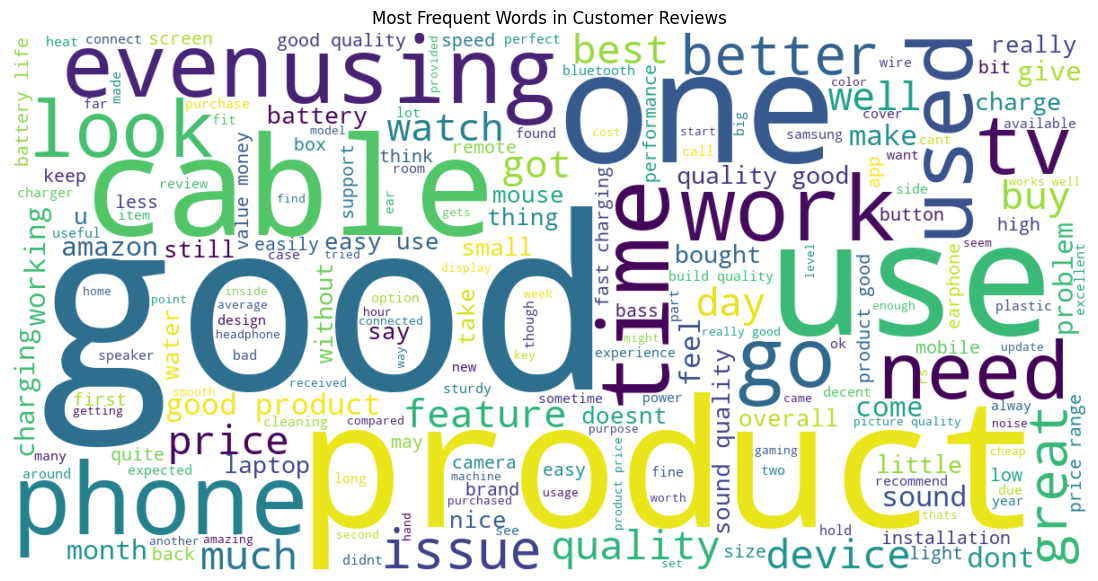

In [22]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(filtered_words)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Customer Reviews")
plt.show()

The word cloud visualization highlights the dominant themes present in customer reviews.

Words such as "good", "quality", "work", and "better" appear prominently, indicating generally positive customer experiences and satisfaction with product performance.

At the same time, product-related terms including "cable", "phone", "tv", "battery", and "charging" reflect the strong presence of electronics and accessory products within the dataset.

The prominence of terms like "price" and "buy" also suggests that affordability and purchasing decisions are important factors in customer feedback.

Although positive terms dominate the visualization, words such as "issue" and "problem" indicate that some customers also mention product-related concerns and usability issues.

### Sentiment Analysis 

Sentiment analysis was performed to quantify the emotional tone of customer reviews and classify them as positive, negative, or neutral.

In [23]:
df["sentiment_score"] = (
    df["review_content"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
)

def classify_sentiment(score):
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"
    
df["sentiment_label"] = (
    df["sentiment_score"].apply(classify_sentiment)
)

df["sentiment_label"].value_counts()

sentiment_label
Positive    1439
Negative      22
Neutral        1
Name: count, dtype: int64

The sentiment analysis results strongly support the earlier rating distribution findings.

Most customer reviews were classified as positive, while only a very small number of reviews showed negative sentiment. This indicates generally high customer satisfaction across the product catalog and is consistent with the dominance of positive terms observed during the text analysis stage.

<Axes: xlabel='sentiment_label'>

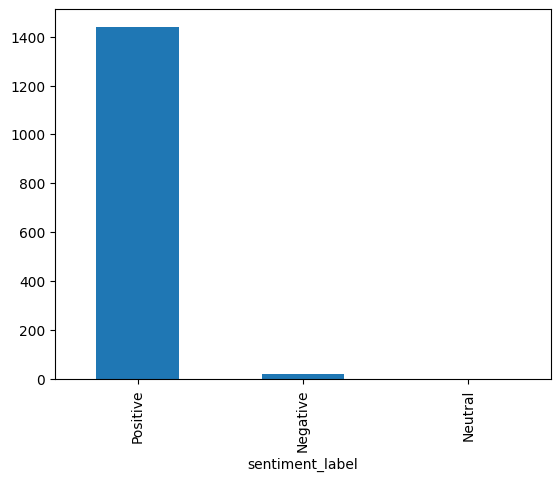

In [24]:
df["sentiment_label"].value_counts().plot(kind="bar")

### Sentiment Score Distribution

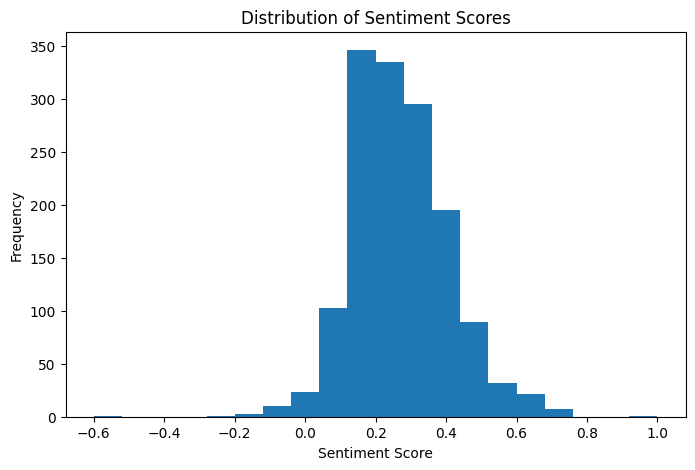

In [25]:
plt.figure(figsize=(8, 5))

plt.hist(df["sentiment_score"], bins=20)

plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")

plt.show()

The sentiment score distribution is concentrated on the positive side of the scale, with only a small number of negative sentiment observations. This pattern further supports the earlier findings of generally positive customer satisfaction and review sentiment.

In [26]:
(
    df["sentiment_label"]
    .value_counts(normalize=True)
    *100
).round(2)

sentiment_label
Positive    98.43
Negative     1.50
Neutral      0.07
Name: proportion, dtype: float64

Sentiment analysis shows that customer reviews are overwhelmingly positive.

Approximately 98.43% of reviews were classified as positive, while only 1.50% were negative and 0.07% were neutral.

These findings are consistent with the high average product rating and suggest strong overall customer satisfaction.

### Sentiment vs Rating  Relationship

                   rating  sentiment_score
rating           1.000000         0.177735
sentiment_score  0.177735         1.000000


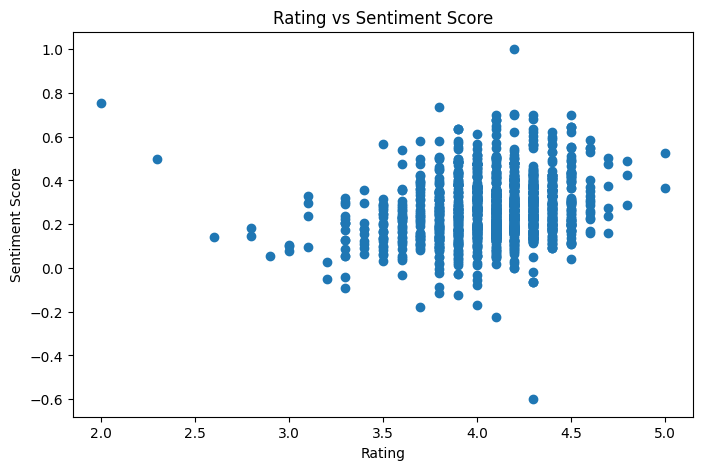

In [27]:
correlation = df[["rating", "sentiment_score"]].corr()
print(correlation)

plt.figure(figsize=(8, 5))
plt.scatter(df["rating"], df["sentiment_score"])

plt.title("Rating vs Sentiment Score")
plt.xlabel("Rating")
plt.ylabel("Sentiment Score")
plt.show()

The correlation between product ratings and sentiment scores is positive but relatively weak (0.18).

This suggests that products with higher ratings tend to receive slightly more positive review language. However, the relationship is not particularly strong.

One possible explanation is the limited variation in product ratings, as most products already have ratings clustered between 4.0 and 4.5. This restricted range makes it more difficult to observe a stronger linear relationship between ratings and sentiment scores.

### Most Negative Customer Reviews

The reviews with the lowest sentiment scores were examined to identify the main sources of customer dissatisfaction and recurring product issues.

In [28]:
df[[
    "product_name",
    "main_category",
    "rating",
    "sentiment_score",
    "review_content"
]].sort_values(by="sentiment_score").head(10)

,product_name,main_category,rating,sentiment_score,review_content
155,7SEVEN® Compatible for Tata Sky Remote Origina...,Electronics,4.3,-0.600000,tv on off not working so difficult to battery ...
1237,Havells Bero Quartz Heater Black 800w 2 Heat S...,Home&Kitchen,4.1,-0.225000,like and happyplease dont buy this heater it s...
145,Airtel DigitalTV DTH Remote SD/HD/HD Recording...,Electronics,3.7,-0.179762,value of moneyusually gdgood productgoodqualit...
1463,Havells Ventil Air DSP 230mm Exhaust Fan (Pist...,Home&Kitchen,4.0,-0.170167,i have installed this in my kitchen working fi...
1198,Crompton Sea Sapphira 1200 mm Ultra High Speed...,Home&Kitchen,3.9,-0.122500,not a eassy to bare this product in this produ...
1367,ESN 999 Supreme Quality 1500W Immersion Water ...,Home&Kitchen,3.8,-0.112500,this product of yours company is heating liter...
275,LOHAYA Voice Assistant Remote Compatible for A...,Electronics,3.3,-0.091071,okvery disappointedrange is not good it doesnt...
681,Quantum QHM-7406 Full-Sized Keyboard with (₹) ...,Computers&Accessories,3.8,-0.086458,comfortable keys and smooth typinggoodaverageo...
738,Callas Multipurpose Foldable Laptop Table with...,Computers&Accessories,4.0,-0.078929,price is high is given in curved shape bench u...
723,Samsung 80 cm (32 Inches) Wondertainment Serie...,Electronics,4.3,-0.063214,overall goodtv picture ok smart bettersound ve...


The most negative reviews reveal recurring complaints related to product functionality, durability, and usability issues.

Several reviews mention problems such as devices not working properly, heating inefficiency, battery-related issues, and unmet performance expectations. Despite some products having relatively high numerical ratings, their review texts still contain strongly negative expressions, highlighting the importance of text-based sentiment analysis alongside rating scores.

These findings help identify potential product weaknesses and areas where customer experience could be improved.

### Most Positive Customer Reviews

In [29]:
df[[
    "product_name",
    "main_category",
    "rating",
    "sentiment_score",
    "review_content",
]].sort_values(by="sentiment_score",ascending=False).head(10)

,product_name,main_category,rating,sentiment_score,review_content
302,Technotech High Speed HDMI Cable 5 Meter V1.4 ...,Electronics,4.2,1.000000,okquality perfect perfect m must buyokexcellen...
1309,Khaitan ORFin Fan heater for Home and kitchen-...,Home&Kitchen,2.0,0.755000,the heating capacity is zero moreover i have i...
872,CP PLUS 2MP Full HD Smart Wi-fi CCTV Security ...,Electronics,3.8,0.735000,great product go for itvery nicepicture qualit...
1209,Bajaj DHX-9 1000W Heavy Weight Dry Iron with A...,Home&Kitchen,4.2,0.704167,good product weight is reduced a bitdamage pro...
987,Foxin FTC 12A / Q2612A Black Laser Toner Cartr...,Computers&Accessories,4.1,0.700000,product is good print quality is goodsuper pri...
134,AmazonBasics New Release ABS USB-A to Lightnin...,Computers&Accessories,4.2,0.700000,cable otherwise goodi like the productquality ...
625,Seagate Expansion 1TB External HDD - USB 3.0 f...,Computers&Accessories,4.5,0.700000,good onegudhard disk is good but data cable qu...
750,Eveready Red 1012 AAA Batteries - Pack of 10,Electronics,4.3,0.700000,nivevery good batteries receivedlikegood produ...
724,"Logitech B100 Wired USB Mouse, 3 yr Warranty, ...",Computers&Accessories,4.3,0.679091,liked this product for a laptop perfectly work...
658,"boAt Micro USB 55 Tangle-free, Sturdy Micro US...",Computers&Accessories,4.1,0.677778,build quality is good and it is comes with yea...


The most positive reviews frequently include strongly favorable expressions such as "perfect", "excellent", "good", and "must buy", indicating very high customer satisfaction.

Positive feedback is primarily associated with product quality, ease of use, reliability, and overall performance. Electronics and Computers & Accessories products appear most frequently among the highest sentiment reviews, suggesting strong customer approval within these categories.

Overall, the positive reviews reinforce earlier findings that the dataset is dominated by highly satisfied customers and generally favorable product experiences.

### Sentiment Analysis by Category

Average sentiment scores were calculated for each main product category to compare customer satisfaction levels across different product groups.

In [30]:
category_sentiment = df.groupby(by="main_category")[[
    "sentiment_score",
    "rating",
    "rating_count"
]].mean()

category_sentiment.sort_values(by="sentiment_score", ascending=False)

,sentiment_score,rating,rating_count
main_category,,,
Toys&Games,0.371966,4.300000,15867.000000
OfficeProducts,0.325990,4.309677,4828.225806
Computers&Accessories,0.287764,4.155654,17136.782705
Home&Kitchen,0.267686,4.040716,6689.210291
Car&Motorbike,0.258214,3.800000,1118.000000
Electronics,0.256671,4.081749,29997.809886
HomeImprovement,0.211858,4.250000,4283.000000
MusicalInstruments,0.197097,3.900000,44441.000000
Health&PersonalCare,0.161032,4.000000,3663.000000


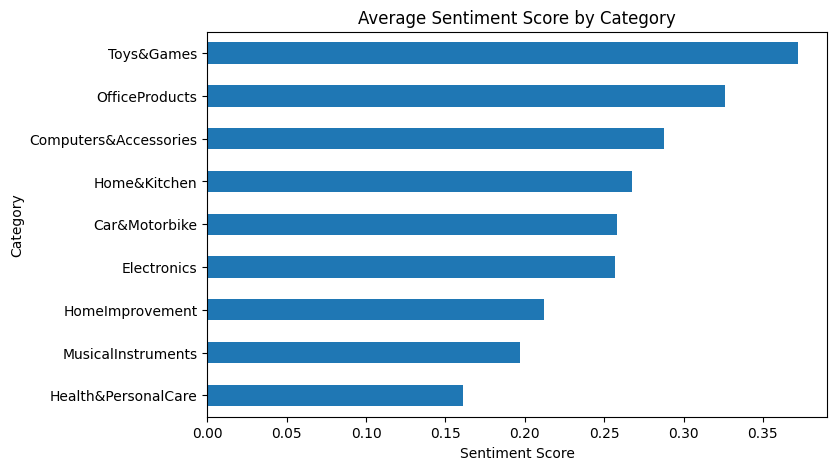

In [31]:
category_sentiment.sort_values(
    by="sentiment_score"
)["sentiment_score"].plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Average Sentiment Score by Category")
plt.xlabel("Sentiment Score")
plt.ylabel("Category")

plt.show()

Categories with lower technical complexity, such as Toys & Games and Office Products, achieved the highest sentiment scores.

In contrast, Electronics and Home & Kitchen showed relatively lower sentiment scores despite maintaining high average ratings.

Category-level sentiment analysis reveals noticeable differences in customer review tone across product groups.

Toys & Games and Office Products achieved the highest average sentiment scores, suggesting that customers tend to express more positive experiences with simpler and lower-risk products.

In contrast, categories such as Electronics and Home & Kitchen received comparatively lower sentiment scores despite maintaining relatively high average ratings. This pattern may reflect higher customer expectations, increased technical complexity, and a greater likelihood of performance-related issues in these product categories.

Overall, the findings indicate that customer sentiment is influenced not only by product quality, but also by product complexity, usability, and expectations associated with different categories.

### TF-IDF Vectorization

Customer reviews were transformed into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency), which assigns higher weights to informative words and lower weights to commonly used terms.

In [32]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X_tfidf = tfidf.fit_transform(df["review_content"])

X_tfidf

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 76320 stored elements and shape (1462, 1000)>

The customer review corpus was transformed into a TF-IDF matrix containing 1,000 textual features across 1,462 reviews.

Each review was represented as a numerical feature vector, allowing machine learning models to identify important linguistic patterns and evaluate customer sentiment based on textual information.

By assigning higher weights to distinctive terms and lower weights to commonly occurring words, TF-IDF helps emphasize more informative features within the review corpus.

### Train-Test Split

The TF-IDF feature matrix was divided into training and testing sets to evaluate the sentiment classification model on unseen review data.

In [33]:
df_ml = df[df["sentiment_label"] != "Neutral"].copy()

X = tfidf.fit_transform(df_ml["review_content"])
y = df_ml["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The TF-IDF feature matrix was divided into training and testing sets to evaluate model performance on unseen review data.

Because only one review was classified as Neutral, this category was excluded from the machine learning stage to avoid issues during stratified train-test splitting.

The final model was therefore designed as a binary sentiment classifier distinguishing between Positive and Negative customer reviews.

An 80/20 train-test split was applied, with stratification used to preserve the original class distribution in both subsets.

### Logistic Regression Model

A Logistic Regression model was trained to classify customer reviews as Positive or Negative based on TF-IDF textual features.

Logistic Regression is a widely used and highly effective algorithm for text classification tasks due to its simplicity, interpretability, and strong performance on sparse feature matrices.

In [34]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


The Logistic Regression model was trained using the TF-IDF feature matrix to learn patterns associated with positive and negative customer sentiment.

### Sentiment Prediction

The trained model was used to predict sentiment labels for the test dataset.

In [35]:
y_pred = model.predict(X_test)

### Model Evaluation

Classification performance was evaluated using accuracy, precision, recall, and F1-score.

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9863

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         4
    Positive       0.99      1.00      0.99       289

    accuracy                           0.99       293
   macro avg       0.49      0.50      0.50       293
weighted avg       0.97      0.99      0.98       293



c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

Although the model achieved very high overall accuracy, it failed to correctly identify negative reviews due to the severe class imbalance in the dataset. Since positive reviews dominate the data, the classifier tends to predict the majority class, leading to poor performance on minority negative samples.

In [37]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train,y_train)
  
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9863

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         4
    Positive       0.99      0.99      0.99       289

    accuracy                           0.99       293
   macro avg       0.75      0.75      0.75       293
weighted avg       0.99      0.99      0.99       293



After applying class balancing, the model showed a substantially improved ability to identify minority Negative reviews.

Although overall accuracy remained high, the recall and F1-score for the Negative class increased significantly compared to the initial model, indicating more effective handling of class imbalance.

These results demonstrate that relying solely on accuracy can be misleading in highly imbalanced datasets, as strong overall performance may still conceal poor minority-class detection.

### Confusion Matrix

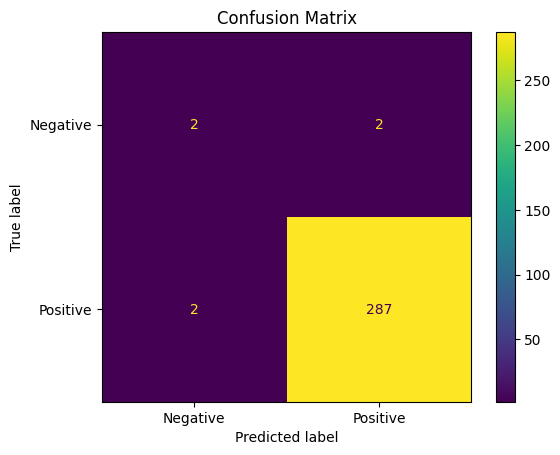

In [38]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

The confusion matrix confirms that the balanced Logistic Regression model improved its ability to detect minority Negative reviews while still maintaining very strong performance on Positive reviews.

The model correctly identified 287 Positive reviews and 2 Negative reviews. However, some misclassifications remain due to the severe class imbalance and the very limited number of negative samples available in the dataset.

Overall, the results demonstrate that class balancing significantly improved minority-class detection compared to the initial model, where Negative reviews were not identified at all.

### Most Predictive Words

The coefficients of the Logistic Regression model were analyzed to identify the words that most strongly contribute to Positive and Negative sentiment predictions.

In [39]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "Words" : feature_names,
    "Coef" : coefficients
})


top_positive = coef_df.sort_values(
    by="Coef",
    ascending=False
).head(20)

top_negative = coef_df.sort_values(
    by="Coef"
).head(20)

print("Top Positive Words")
display(top_positive)

print("Top Negative Words")
display(top_negative)

Top Positive Words


,Words,Coef
331,good,4.168697
251,easy,1.560777
697,quality,1.520849
985,works,1.433662
96,cable,1.338503
817,sound,1.279797
63,best,1.263263
592,original,1.232254
663,price,1.091503
468,light,1.027179


Top Negative Words


,Words,Coef
648,poor,-2.734877
819,space,-2.433894
955,waste,-2.363764
801,slow,-2.344460
47,bad,-2.265368
830,stand,-2.231704
94,buy,-1.996365
219,difficult,-1.987430
72,bluetooth,-1.817772
519,mention,-1.758248


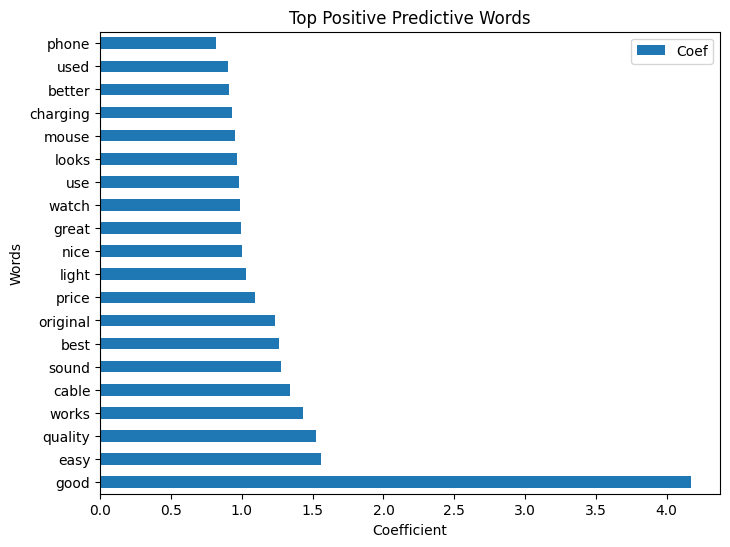

In [40]:
top_positive.plot(
    kind="barh",
    x="Words",
    y="Coef",
    figsize=(8,6)
)

plt.title("Top Positive Predictive Words")
plt.xlabel("Coefficient")
plt.ylabel("Words")
plt.show()

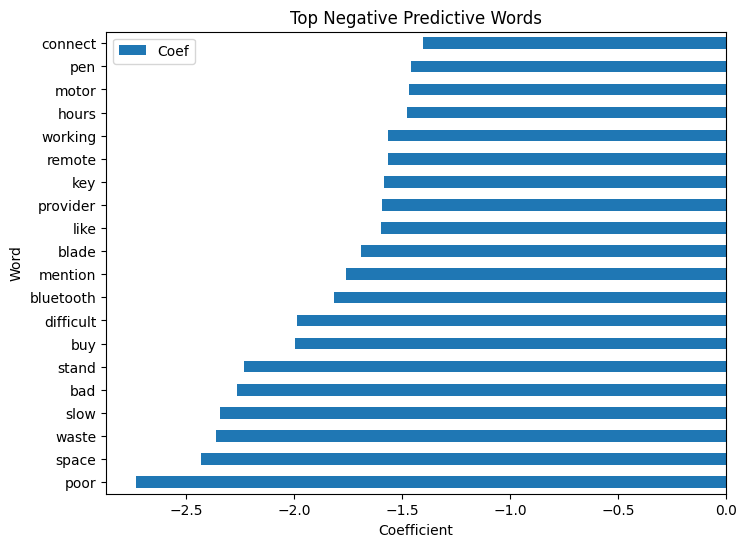

In [41]:
top_negative.plot(
    kind="barh",
    x="Words",
    y="Coef",
    figsize=(8, 6)
)

plt.title("Top Negative Predictive Words")
plt.xlabel("Coefficient")
plt.ylabel("Word")
plt.show()

The coefficient analysis of the Logistic Regression model identified the words that most strongly influenced sentiment predictions.

Words such as "good", "easy", "quality", "works", and "best" were among the strongest indicators of positive sentiment, suggesting that customer satisfaction is primarily associated with product performance, usability, and overall quality.

Conversely, words including "poor", "waste", "slow", "bad", and "difficult" showed strong negative coefficients, indicating dissatisfaction related to low product quality, usability issues, and poor performance.

The results also demonstrate that the model successfully captured meaningful linguistic patterns from customer reviews, improving interpretability by revealing the specific terms most associated with positive and negative sentiment classifications.

## Final Insights

This project explored customer reviews, product ratings, pricing behavior, and sentiment patterns using exploratory data analysis, natural language processing, and machine learning techniques.

The analysis revealed that customer satisfaction is generally very high across the dataset, with positive sentiment dominating most reviews. Products with strong ratings and substantial review engagement tended to achieve the highest overall scores, while lower-priced categories often delivered the strongest value scores.

Text mining and sentiment analysis showed that customers primarily focus on product quality, usability, performance, and value for money when writing reviews. Positive reviews frequently emphasized terms such as "good", "quality", and "easy", whereas negative reviews were more strongly associated with words like "poor", "slow", and "difficult".

The Logistic Regression model successfully learned meaningful linguistic patterns from customer reviews using TF-IDF vectorization. After applying class balancing techniques, the model improved its ability to identify minority negative reviews while maintaining high overall classification performance.

Overall, the project demonstrates how customer review data can be transformed into actionable business insights through data analysis, NLP preprocessing, sentiment analysis, and machine learning modeling.